# **Laboratory Summative Activity**

***Fuzzy Logic Analysis of Credit Card Default Risk Using the Credit Card Clients Dataset***

*CHRISTIAN C. FRIOLO*

*BCS42*

*03.10.2026*

In [ ]:
!pip install scikit-fuzzy

**IMPORT LIBRARIES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Load dataset using the second row (index 1) as the header
df = pd.read_csv("credit_card_clients.csv", header=1)


# Starts in 2nd row
df[['LIMIT_BAL','PAY_0','PAY_AMT1','default payment next month']]

,LIMIT_BAL,PAY_0,PAY_AMT1,default payment next month
0,20000,2,0,1
1,120000,-1,0,1
2,90000,0,1518,0
3,50000,0,2000,0
4,50000,-1,2000,0
...,...,...,...,...
29995,220000,0,8500,0
29996,150000,-1,1837,0
29997,30000,4,0,1
29998,80000,1,85900,1


**DEFINE FUZZY VARIABLES**

In [ ]:
# Input variables
credit_limit = ctrl.Antecedent(np.arange(0,1000001,1000),'credit_limit')
payment_status = ctrl.Antecedent(np.arange(-2,10,1),'payment_status')
payment_amount = ctrl.Antecedent(np.arange(0,500000,1000),'payment_amount')

# Output variable
credit_risk = ctrl.Consequent(np.arange(0,11,1),'credit_risk')

**MEMBERSHIP FUNCTIONS**

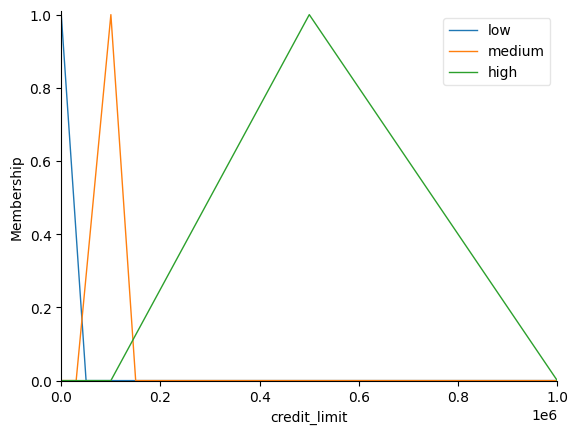

In [ ]:
credit_limit['low'] = fuzz.trimf(credit_limit.universe,[0,0,50000])
credit_limit['medium'] = fuzz.trimf(credit_limit.universe,[30000,100000,150000])
credit_limit['high'] = fuzz.trimf(credit_limit.universe,[100000,500000,1000000])

credit_limit.view()

**PAYMENT STATUS**

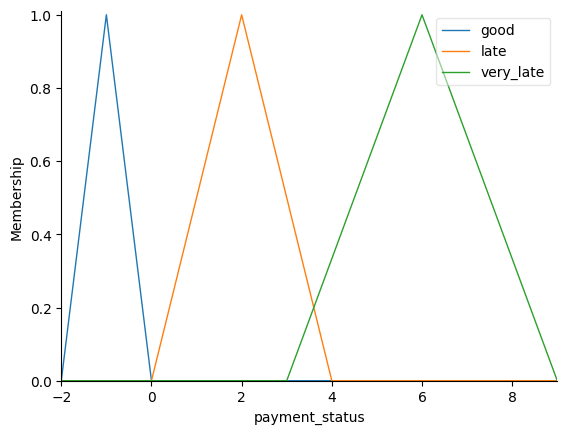

In [ ]:
payment_status['good'] = fuzz.trimf(payment_status.universe,[-2,-1,0])
payment_status['late'] = fuzz.trimf(payment_status.universe,[0,2,4])
payment_status['very_late'] = fuzz.trimf(payment_status.universe,[3,6,9])

payment_status.view()

**PAYMENT AMOUNT**

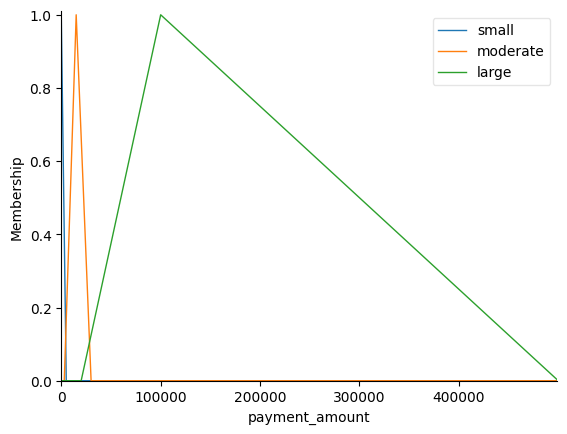

In [ ]:
payment_amount['small'] = fuzz.trimf(payment_amount.universe,[0,0,5000])
payment_amount['moderate'] = fuzz.trimf(payment_amount.universe,[3000,15000,30000])
payment_amount['large'] = fuzz.trimf(payment_amount.universe,[20000,100000,500000])

payment_amount.view()

**OUTPUT OF THE CREDIT RISK**

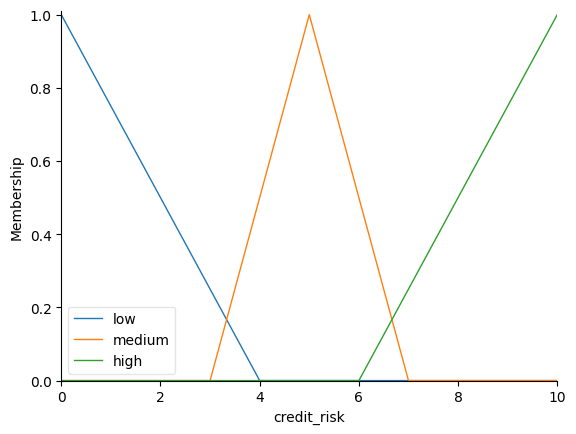

In [ ]:
credit_risk['low'] = fuzz.trimf(credit_risk.universe,[0,0,4])
credit_risk['medium'] = fuzz.trimf(credit_risk.universe,[3,5,7])
credit_risk['high'] = fuzz.trimf(credit_risk.universe,[6,10,10])

credit_risk.view()

**FUZZY RULES**

In [ ]:
rule1 = ctrl.Rule(credit_limit['low'] & payment_status['very_late'], credit_risk['high'])

rule2 = ctrl.Rule(credit_limit['medium'] & payment_status['late'], credit_risk['medium'])

rule3 = ctrl.Rule(credit_limit['high'] & payment_status['good'], credit_risk['low'])

rule4 = ctrl.Rule(payment_amount['small'] & payment_status['late'], credit_risk['high'])

rule5 = ctrl.Rule(payment_amount['large'] & payment_status['good'], credit_risk['low'])

In [ ]:
risk_ctrl = ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5])
risk_simulation = ctrl.ControlSystemSimulation(risk_ctrl)

## **Guide Question Answers**

### **Question 1**

**Based on the Credit Limit graph, what credit category does a client with LIMIT_BAL = 40,000 belong to?**

**Answer:**
A client with a credit limit of 40,000 primarily belongs to the Low Credit Limit category, but it also has a partial membership in the Medium Credit Limit category.

**Interpretation:**
In fuzzy logic, values can belong to more than one category at the same time. Based on the triangular membership functions:

*   **Low:** [0, 0, 50,000]
*   **Medium:** [30,000, 100,000, 150,000]

At 40,000, the client has:

*   A membership value of about 0.2 in the Low category
*   A membership value of about 0.14 in the Medium category

Since the Low membership value is slightly higher, the system interprets the client mainly as a low credit limit holder, but still partially related to the medium category. This overlapping classification reflects the flexibility of fuzzy logic in representing real-world financial situations.

### **Question 2**

**What happens to the credit risk when payment status changes from Good to Very Late?**

**Answer:**
When the payment status changes from Good to Very Late, the predicted credit risk significantly increases, usually shifting from Low or Medium Risk to High Risk.

**Interpretation:**
In the fuzzy rule system, payment behavior strongly influences credit risk.

*   When the payment status is Good, the system activates rules that typically lead to Low Risk, especially when combined with good payment amounts or higher credit limits.
*   When the status changes to Very Late, rules associated with poor repayment behavior are triggered. These rules map directly to the High Credit Risk output.

This means that late payments are interpreted by the system as a strong indicator of potential financial instability.

### **Question 3**

**If a client has: Credit Limit = 200,000, Payment Status = Good, Payment Amount = Large, what is the expected risk?**

**Answer:**
The expected result for this client profile is Low Credit Risk.

**Interpretation:**
This combination represents a financially stable borrower:

*   High credit limit (200,000) suggests strong credit capacity.
*   Good payment status indicates responsible repayment behavior.
*   Large payment amount shows the ability to pay significant portions of debt.

These conditions activate fuzzy rules associated with low-risk borrowers, causing the defuzzified result to fall near the lower end of the risk scale (around 0–4). As a result, the system classifies the borrower as having low probability of default.

### **Question 4**

**Why is fuzzy logic suitable for credit risk evaluation?**

**Answer:**
Fuzzy logic is suitable for credit risk evaluation because financial behavior is not strictly binary; it exists on a spectrum.

**Interpretation:**
Traditional decision systems often rely on strict thresholds (for example, approving or rejecting a client based on a single cutoff value). However, real-world financial behavior is more complex.

Fuzzy logic allows:

*   Partial membership in multiple categories
*   Gradual transitions between risk levels
*   Human-like reasoning using linguistic terms such as low, medium, or high risk

For example, a borrower may not be entirely risky but may show moderate warning signs, such as slightly late payments or moderate credit utilization. Fuzzy systems capture these nuances better than rigid rule-based models.

### **Question 5**

**Compare the fuzzy prediction with the actual dataset variable Y.**

**Answer:**
The fuzzy system produces a risk score, while the dataset variable Y represents the actual default outcome.

**Interpretation:**

The dataset variable Y is binary:

*   1 = Default occurred
*   0 = No default

The fuzzy system produces a continuous risk value between 0 and 10, representing the severity or likelihood of default risk.

This means the fuzzy model provides early risk estimation, rather than a simple yes-or-no result. If many clients with high fuzzy risk scores also have Y = 1, it indicates that the fuzzy model is effective at predicting default tendencies.

Such predictions can help financial institutions identify risky clients earlier and take preventive actions, such as adjusting credit limits or monitoring repayment behavior.